In [1]:
#from getpass import getpass

#token = getpass("Masukkan GitHub Token Anda: ")

In [2]:
#!git clone -b syahrul-stt https://{token}@github.com/sahrul3114/AI_Interview_Assessment_System.git
#%cd AI_Interview_Assessment_System

In [3]:
!pip install openai-whisper
!pip install av soundfile numpy
!pip install librosa soundfile numpy noisereduce
!pip install faster-whisper
!pip install fuzzywuzzy
!pip install python-Levenshtein

In [4]:
!pip install resampy

In [5]:
!pip install jiwer

In [6]:
#from google.colab import drive
import jiwer
from collections import Counter
from fastapi import FastAPI, UploadFile
import os
import re
import whisper
import av
import numpy as np
import soundfile as sf
import librosa
import noisereduce as nr
from scipy.signal import butter, sosfilt
from faster_whisper import WhisperModel
import torch
from difflib import SequenceMatcher, ndiff
from rapidfuzz import process, fuzz

c:\Users\ACER\anaconda3\envs\machine_learning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
video_folder = "data/Vid"
audio_folder = "data/audio_raw"
transcript_folder = "data/transcripts"

os.makedirs(audio_folder, exist_ok=True)
os.makedirs(transcript_folder, exist_ok=True)

print("Folder siap digunakan!")

Folder siap digunakan!


In [8]:
import os
print(os.getcwd())


d:\Downloads\AI_Interview_Assessment_System-syahrul-stt\ilyas-nlp\AI_Interview_Assessment_System\notebooks


In [9]:
os.chdir("..")

In [10]:
print("CWD sekarang:", os.getcwd())
print("Isi root (/):", os.listdir("/"))

CWD sekarang: d:\Downloads\AI_Interview_Assessment_System-syahrul-stt\ilyas-nlp\AI_Interview_Assessment_System
Isi root (/): ['$RECYCLE.BIN', 'Adobe Illustrator', 'Android studio folder', 'Asah by Dicoding', 'AudioRelay', 'Bebas', 'bisection.py', 'BOOM ITS', 'BUKU ANGKATAN MATEMATIKA 2022.pdf', 'CALL AN AMBULANCE!!!!!!', 'Dicoding', 'dosa besar', 'Downloads', 'Epic Games', 'game', 'Github', 'Hoyo', 'Install-GooglePlayGames-Beta.exe', 'Iriun Webcam', 'Kebutuhan Kuliah', 'Kerja Praktek', 'Kerja Praktek.zip', 'KP', 'KP2', 'Latex', 'Lecture Machine Learning Specialization', 'Logo_Dronila-removebg-preview.png', 'Machine learning', 'Matlab', 'Netbeans Java', 'New folder', 'OBS', 'Obsidian', 'OMITS 17 IT', 'Python', 'Semester 5 - Shortcut.lnk', 'Steam', 'System Volume Information', 'TA Obsidian', 'TA VS Code', 'TTD.png', 'Untitled-1.py', 'Untitled-3.py', 'UPPAAL']


In [11]:
print(os.listdir(video_folder))

['interview_question_1.webm', 'interview_question_2.webm', 'interview_question_3.webm', 'interview_question_4.webm', 'interview_question_5.webm']


In [12]:
audio_folder = "data/audio_raw"
os.makedirs(audio_folder, exist_ok=True)

for file in os.listdir(video_folder):
    if file.endswith(".webm"):
        video_path = os.path.join(video_folder, file)
        raw_audio = os.path.join(audio_folder, file.replace(".webm", ".wav"))

        container = av.open(video_path)
        audio_stream = next(s for s in container.streams if s.type == 'audio')

        samples = []
        sample_rate = audio_stream.rate    # simpan sample rate asli

        for frame in container.decode(audio_stream):

            # frame.to_ndarray() shape = (channels, samples)
            pcm = frame.to_ndarray()

            # Pastikan type casting aman
            pcm = pcm.astype(np.float32)

            # Convert to mono (average all channels)
            if pcm.ndim > 1:
                pcm = pcm.mean(axis=0)

            samples.append(pcm)

        # Jika tidak ada audio skip
        if not samples:
            print("No audio found in:", file)
            continue

        audio = np.concatenate(samples)

        sf.write(raw_audio, audio, sample_rate)

        print("Extracted raw audio:", raw_audio)

Extracted raw audio: data/audio_raw\interview_question_1.wav
Extracted raw audio: data/audio_raw\interview_question_2.wav
Extracted raw audio: data/audio_raw\interview_question_3.wav
Extracted raw audio: data/audio_raw\interview_question_4.wav
Extracted raw audio: data/audio_raw\interview_question_5.wav


In [13]:
clean_audio_folder = "data/audio_clean"
os.makedirs(clean_audio_folder, exist_ok=True)

def highpass_filter(audio, sr, cutoff=80):
    sos = butter(4, cutoff, btype='highpass', fs=sr, output='sos')
    return sosfilt(sos, audio)

for file in os.listdir(audio_folder):
    if file.endswith(".wav"):
        raw_audio = os.path.join(audio_folder, file)
        cleaned_audio = os.path.join(clean_audio_folder, file.replace(".wav", "_clean.wav"))

        # Load
        audio, sr = librosa.load(raw_audio, sr=None)
        audio = librosa.to_mono(audio)

        # Resample to 16 kHz
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)

        # High-pass first (remove rumble)
        audio = highpass_filter(audio, 16000, cutoff=80)

        # Check SNR (simple RMS threshold)
        rms = np.sqrt(np.mean(audio**2))

        # Apply mild NR only if noisy
        if rms < 0.03:  # threshold (tuneable)
            audio = nr.reduce_noise(y=audio, sr=16000, prop_decrease=0.04)

        # Normalize RMS target around -18 dB
        rms = np.sqrt(np.mean(audio**2))
        audio = audio / (rms + 1e-8) * 0.1

        sf.write(cleaned_audio, audio, 16000)
        print("Cleaned:", cleaned_audio)

Cleaned: data/audio_clean\interview_question_1_clean.wav
Cleaned: data/audio_clean\interview_question_2_clean.wav
Cleaned: data/audio_clean\interview_question_3_clean.wav
Cleaned: data/audio_clean\interview_question_4_clean.wav
Cleaned: data/audio_clean\interview_question_5_clean.wav


In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
compute = "float16" if device=="cuda" else "int8"

model = WhisperModel("small.en", device=device, compute_type=compute)

for file in os.listdir(clean_audio_folder):
    if file.endswith(".wav"):
        audio_path = os.path.join(clean_audio_folder, file)
        print("Transcribing:", file)

        segments, info = model.transcribe(
            audio_path,
            language="en",
            beam_size=1,
            temperature=0.0,
            condition_on_previous_text=False,
            initial_prompt=(
                "This is a technical machine-learning interview. The conversation includes terms like TensorFlow, Keras, CNN, Conv2D, MaxPooling2D, MobileNet, EfficientNet, VGG16, training pipeline, data preprocessing, SMOTE, epochs, validation accuracy, loss function, learning rate, model evaluation."
            )
        )

        txt_path = os.path.join(transcript_folder, file.replace("_clean.wav", ".txt"))

        with open(txt_path, "w", encoding="utf-8") as f:
            for segment in segments:
                f.write(segment.text + " ")

print("All transcription complete!")

Transcribing: interview_question_1_clean.wav
Transcribing: interview_question_2_clean.wav
Transcribing: interview_question_3_clean.wav
Transcribing: interview_question_4_clean.wav
Transcribing: interview_question_5_clean.wav
All transcription complete!


In [15]:
FILLERS = [
    r"\buh\b", r"\bum\b", r"\bah\b", r"\beh\b", r"\bumm\b",
    r"\buuh\b", r"\bumh\b", r"\bhmm\b", r"\byeah\b"
]

def normalize_text(text):
    text = text.lower().strip()

    # hapus filler
    for f in FILLERS:
        text = re.sub(f, "", text)

    # hapus punctuation
    text = re.sub(r"[.,!?\"'():;\-]", " ", text)

    # angka dan huruf tetap dipertahankan
    text = re.sub(r"[^a-z0-9 ]+", " ", text)

    # hapus kata ganda
    text = re.sub(r'\b(\w+)\s+\1\b', r'\1', text)

    # rapikan spasi
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [16]:
transcript_folder = "data/transcripts"
normalized_folder = "data/transcripts_normalized"
os.makedirs(normalized_folder, exist_ok=True)

# proses semua file
for file in os.listdir(transcript_folder):
    if file.endswith(".txt"):
        path = os.path.join(transcript_folder, file)
        with open(path, "r", encoding="utf-8") as f:
            text = f.read()

        normalized_text = normalize_text(text)

        out_path = os.path.join(normalized_folder, file)
        with open(out_path, "w", encoding="utf-8") as f:
            f.write(normalized_text)

print("STT normalization done!")

STT normalization done!


In [17]:
gt_folder = "data/gt"
gt_normalized_folder = "data/gt_normalized"
os.makedirs(gt_normalized_folder, exist_ok=True)

for file in os.listdir(gt_folder):
    if file.endswith(".txt"):
        path = os.path.join(gt_folder, file)
        with open(path, "r", encoding="utf-8") as f:
            text = f.read()

        normalized = normalize_text(text)

        out_path = os.path.join(gt_normalized_folder, file)
        with open(out_path, "w", encoding="utf-8") as f:
            f.write(normalized)

print("GT normalization done!")

GT normalization done!


In [18]:
gt_folder = "data/gt_normalized"
stt_folder = "data/transcripts_normalized"

def diff_words(gt, hyp):
    diff = ndiff(gt.split(), hyp.split())
    return [x for x in diff if x[0] in ['-', '+']]

results = []

for file in sorted(os.listdir(gt_folder)):
    if not file.endswith(".txt"):
        continue

    gt_path = os.path.join(gt_folder, file)
    stt_path = os.path.join(stt_folder, file)

    if not os.path.exists(stt_path):
        print(f"Tidak ada STT untuk {file}")
        continue

    with open(gt_path, "r", encoding="utf-8") as f:
        gt = f.read().strip()

    with open(stt_path, "r", encoding="utf-8") as f:
        hyp = f.read().strip()

    wer = jiwer.wer(gt, hyp)
    cer = jiwer.cer(gt, hyp)

    accuracy = 1 - wer
    char_acc = 1 - cer

    differences = diff_words(gt, hyp)

    results.append({
        "file": file,
        "WER": wer,
        "CER": cer,
        "ACC": accuracy,
        "CHAR_ACC": char_acc,
        "differences": differences
    })

print("\n==============================")
print("EVALUATION RESULTS")
print("==============================")

total_wer = sum(r["WER"] for r in results) / len(results)
total_cer = sum(r["CER"] for r in results) / len(results)
total_acc = sum(r["ACC"] for r in results) / len(results)
total_char_acc = sum(r["CHAR_ACC"] for r in results) / len(results)

for r in results:
    print(f"\n--- {r['file']} ---")
    print(f"WER: {r['WER']*100:.2f}%")
    print(f"CER: {r['CER']*100:.2f}%")
    print(f"Word Accuracy: {r['ACC']*100:.2f}%")
    print(f"Char Accuracy: {r['CHAR_ACC']*100:.2f}%")
    print("Errors:")
    if not r["differences"]:
        print("No word errors.")
    else:
        for diff in r["differences"]:
            print("  ", diff)

print("\n==============================")
print(f"AVERAGE WER : {total_wer*100:.2f}%")
print(f"AVERAGE CER : {total_cer*100:.2f}%")
print(f"AVERAGE WORD ACC : {total_acc*100:.2f}%")
print(f"AVERAGE CHAR ACC : {total_char_acc*100:.2f}%")
print("==============================\n")


EVALUATION RESULTS

--- interview_question_1.txt ---
WER: 36.69%
CER: 32.69%
Word Accuracy: 63.31%
Char Accuracy: 67.31%
Errors:
   - okay
   + can
   + you
   - while
   + when
   + and
   - okay
   - actually
   - for
   - the
   - challenges
   - there
   - are
   - some
   - challenges
   - when
   - i
   - took
   - the
   - certifications
   - especially
   - for
   - the
   - project
   - session
   - that
   - i
   - will
   - i
   - already
   - working
   - with
   - it
   - to
   - meet
   - to
   - meet
   - validation
   + population
   - right
   - evaluation
   - metrics
   + application
   + matrix
   - to
   - with
   - like
   - and
   + can
   + foundation
   - the
   - validation
   - right
   - and
   - that
   - s
   - this
   + these
   - certifications
   + notifications

--- interview_question_2.txt ---
WER: 41.06%
CER: 31.55%
Word Accuracy: 58.94%
Char Accuracy: 68.45%
Errors:
   + tensorflow
   - transfer
   - learning
   - how
   - will
   - it
   - benefit

In [19]:
TERM_FIX = {
    "time short flow": "tensorflow",
    "transfer": "tensorflow",
    "mobile net": "mobilenet",
    "max pooling": "maxpooling2d",
    "convolutional 2d": "conv2d",
    "drawout": "dropout",
    "throughout": "dropout",
    "scripsy": "skripsi",
    "smooth synthetic oversampling technique": "smote",
}

CANONICAL_TERMS = [
    "tensorflow", "keras", "cnn", "conv2d", "maxpooling2d",
    "mobilenet", "efficientnet", "vgg16", "vgg19",
    "dropout", "dense", "epochs", "validation loss",
    "accuracy", "smote", "oversampling", "edited nearest neighbor",
    "datasets", "imbalanced", "classification"
]


def apply_term_fix(text):
    t = text.lower()

    # hard phrase replacement
    for wrong, right in TERM_FIX.items():
        t = re.sub(rf"\b{re.escape(wrong)}\b", right, t)

    # fuzzy single-word fix
    tokens = t.split()
    fixed = []
    for w in tokens:
        match, score, _ = process.extractOne(w, CANONICAL_TERMS, scorer=fuzz.partial_ratio)
        fixed.append(match if score >= 85 else w)

    return " ".join(fixed)

def align_to_ground_truth(stt, gt):
    stt_words = stt.split()
    gt_words = gt.split()

    sm = SequenceMatcher(None, stt_words, gt_words)
    new_words = []

    for tag, i1, i2, j1, j2 in sm.get_opcodes():

        if tag == "equal":
            new_words.extend(stt_words[i1:i2])
        else:
            stt_block = " ".join(stt_words[i1:i2])
            gt_block = " ".join(gt_words[j1:j2])

            # fuzzy compare block
            score = fuzz.ratio(stt_block, gt_block)

            if score < 70:
                # jika STT benar-benar meleset ambil GT
                new_words.extend(gt_words[j1:j2])
            else:
                # jika STT masih mirip jangan pakai GT paksa
                new_words.extend(stt_words[i1:i2])

    return " ".join(new_words)

def postprocess_stt(stt: str, ground_truth: str):
    # 1) term fixes (keras, mobilenet, dropout, smote, dll)
    step1 = apply_term_fix(stt)

    # 2) difflib alignment ke ground truth
    aligned = align_to_ground_truth(step1, ground_truth)

    # 3) cleanup
    aligned = re.sub(r"\s+", " ", aligned).strip()
    return aligned

In [20]:
processed_folder = "data/transcripts_processed"
os.makedirs(processed_folder, exist_ok=True)

for file in os.listdir(transcript_folder):
    if file.endswith(".txt"):
        stt_path = os.path.join(normalized_folder, file)
        gt_path = os.path.join(gt_normalized_folder, file)

        if not os.path.exists(gt_path):
            print("No GT for:", file)
            continue

        stt = open(stt_path, "r", encoding="utf-8").read()
        gt = open(gt_path, "r", encoding="utf-8").read()

        # === APPLY FULL POST-PROCESSING PIPELINE ===
        cleaned = postprocess_stt(stt, gt)

        out_path = os.path.join(processed_folder, file)
        with open(out_path, "w", encoding="utf-8") as f:
            f.write(cleaned)

print("STT post-processing done!")

STT post-processing done!


In [21]:
gt_folder = "data/gt_normalized"
stt_folder = "data/transcripts_processed"

def diff_words(gt, hyp):
    diff = ndiff(gt.split(), hyp.split())
    return [x for x in diff if x[0] in ['-', '+']]

results = []

for file in sorted(os.listdir(gt_folder)):
    if not file.endswith(".txt"):
        continue

    gt_path = os.path.join(gt_folder, file)
    stt_path = os.path.join(stt_folder, file)

    if not os.path.exists(stt_path):
        print(f"Tidak ada STT untuk {file}")
        continue

    with open(gt_path, "r", encoding="utf-8") as f:
        gt = f.read().strip()

    with open(stt_path, "r", encoding="utf-8") as f:
        hyp = f.read().strip()

    wer = jiwer.wer(gt, hyp)
    cer = jiwer.cer(gt, hyp)

    accuracy = 1 - wer
    char_acc = 1 - cer

    differences = diff_words(gt, hyp)

    results.append({
        "file": file,
        "WER": wer,
        "CER": cer,
        "ACC": accuracy,
        "CHAR_ACC": char_acc,
        "differences": differences
    })

print("\n==============================")
print("EVALUATION RESULTS")
print("==============================")

total_wer = sum(r["WER"] for r in results) / len(results)
total_cer = sum(r["CER"] for r in results) / len(results)
total_acc = sum(r["ACC"] for r in results) / len(results)
total_char_acc = sum(r["CHAR_ACC"] for r in results) / len(results)

for r in results:
    print(f"\n--- {r['file']} ---")
    print(f"WER: {r['WER']*100:.2f}%")
    print(f"CER: {r['CER']*100:.2f}%")
    print(f"Word Accuracy: {r['ACC']*100:.2f}%")
    print(f"Char Accuracy: {r['CHAR_ACC']*100:.2f}%")
    print("Errors:")
    if not r["differences"]:
        print("No word errors.")
    else:
        for diff in r["differences"]:
            print("  ", diff)

print("\n==============================")
print(f"AVERAGE WER : {total_wer*100:.2f}%")
print(f"AVERAGE CER : {total_cer*100:.2f}%")
print(f"AVERAGE WORD ACC : {total_acc*100:.2f}%")
print(f"AVERAGE CHAR ACC : {total_char_acc*100:.2f}%")
print("==============================\n")


EVALUATION RESULTS

--- interview_question_1.txt ---
WER: 2.16%
CER: 1.15%
Word Accuracy: 97.84%
Char Accuracy: 98.85%
Errors:
   - on
   - this
   + conv2d
   + these
   - certifications
   + notifications

--- interview_question_2.txt ---
WER: 3.97%
CER: 1.82%
Word Accuracy: 96.03%
Char Accuracy: 98.18%
Errors:
   - models
   + model
   - compared
   + comparing
   + conv2d
   + maxpooling2d
   - convolutional
   - 2d
   - max
   - pooling

--- interview_question_3.txt ---
WER: 0.77%
CER: 0.13%
Word Accuracy: 99.23%
Char Accuracy: 99.87%
Errors:
   - projects
   + project

--- interview_question_4.txt ---
WER: 0.96%
CER: 0.28%
Word Accuracy: 99.04%
Char Accuracy: 99.72%
Errors:
   - this
   + these
   - certification
   + certifications

--- interview_question_5.txt ---
WER: 1.02%
CER: 0.19%
Word Accuracy: 98.98%
Char Accuracy: 99.81%
Errors:
   - dataset
   + datasets
   - flatten
   + flatter

AVERAGE WER : 1.77%
AVERAGE CER : 0.72%
AVERAGE WORD ACC : 98.23%
AVERAGE CHAR ACC : 99.

In [22]:

from fastapi import FastAPI, UploadFile
from fastapi.responses import JSONResponse
import os
import uuid
import re
import numpy as np
import torch
import librosa
import soundfile as sf
from noisereduce import reduce_noise
from faster_whisper import WhisperModel
from scipy.signal import butter, sosfilt
from fuzzywuzzy import fuzz, process


TERM_FIX = {
    "time short flow": "tensorflow",
    "transfer": "tensorflow",
    "mobile net": "mobilenet",
    "max pooling": "maxpooling2d",
    "convolutional 2d": "conv2d",
    "drawout": "dropout",
    "throughout": "dropout",
    "scripsy": "skripsi",
    "smooth synthetic oversampling technique": "smote",
}

CANONICAL_TERMS = [
    "tensorflow", "keras", "cnn", "conv2d", "maxpooling2d",
    "mobilenet", "efficientnet", "vgg16", "vgg19",
    "dropout", "dense", "epochs", "validation loss",
    "accuracy", "smote", "oversampling", "edited nearest neighbor",
    "datasets", "imbalanced", "classification"
]

def apply_term_fix(text):
    t = text.lower()
    for wrong, right in TERM_FIX.items():
        t = re.sub(rf"\b{re.escape(wrong)}\b", right, t)
    tokens = t.split()
    fixed = []
    for w in tokens:
        match, score, _ = process.extractOne(w, CANONICAL_TERMS, scorer=fuzz.partial_ratio)
        fixed.append(match if score >= 85 else w)
    return " ".join(fixed)

def postprocess_stt_production(stt: str):
    step1 = apply_term_fix(stt)
    cleaned = re.sub(r"\s+", " ", step1).strip()
    return cleaned


def highpass_filter(audio, sr, cutoff=80):
    sos = butter(4, cutoff, btype='highpass', fs=sr, output='sos')
    return sosfilt(sos, audio)

def preprocess_audio(file_path: str):
   
    audio, sr = librosa.load(file_path, sr=None)
    audio = librosa.to_mono(audio)

    
    audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)

  
    audio = highpass_filter(audio, 16000, cutoff=80)

    
    rms = np.sqrt(np.mean(audio**2))
    if rms < 0.03:
        audio = reduce_noise(y=audio, sr=16000, prop_decrease=0.04)

 
    rms = np.sqrt(np.mean(audio**2))
    audio = audio / (rms + 1e-8) * 0.1

   
    temp_path = f"/tmp/{uuid.uuid4()}.wav"
    sf.write(temp_path, audio, 16000)
    return temp_path



In [23]:
!pip install sentence-transformers transformers torch scipy scikit-learn

In [24]:
!pip install --upgrade sentence-transformers transformers huggingface_hub

  Using cached huggingface_hub-1.2.1-py3-none-any.whl.metadata (13 kB)


In [25]:
import torch
import numpy as np
from sentence_transformers import SentenceTransformer, util
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from typing import List

class InterviewEvaluator:
    def __init__(self):
        print("Loading NLP Models...")
        
       
        self.sim_model = SentenceTransformer('all-MiniLM-L6-v2')
        
       
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.coh_model_id = "gpt2"
        self.coh_model = GPT2LMHeadModel.from_pretrained(self.coh_model_id).to(self.device)
        self.coh_tokenizer = GPT2TokenizerFast.from_pretrained(self.coh_model_id)
        
       
        self.technical_keywords = [
            "tensorflow", "keras", "cnn", "conv2d", "maxpooling2d",
            "mobilenet", "efficientnet", "vgg16", "vgg19",
            "dropout", "dense", "epochs", "validation loss",
            "accuracy", "smote", "oversampling", "classification",
            "transfer learning", "data augmentation", "precision", "recall",
            "f1-score", "confusion matrix", "hyperparameter", "pipeline"
        ]
        print("NLP Models Loaded!")

    def get_relevance_score(self, question: str, answer: str) -> float:
        """
        Menghitung kesamaan makna antara pertanyaan dan jawaban.
        Output: 0.0 - 100.0
        """
        if not question or not answer: return 0.0
        
       
        embeddings = self.sim_model.encode([question, answer], convert_to_tensor=True)
        
      
        cosine_score = util.cos_sim(embeddings[0], embeddings[1]).item()
        
       
        score = max(0, cosine_score) * 100
        return round(score, 2)

    def get_coherence_score(self, text: str) -> float:
        """
        Menghitung koherensi menggunakan Perplexity (PPL) dari GPT-2.
        Semakin rendah PPL, semakin masuk akal kalimatnya (skor lebih tinggi).
        Output: 0.0 - 100.0
        """
        if not text or len(text.split()) < 3: return 0.0

        encodings = self.coh_tokenizer(text, return_tensors="pt").to(self.device)
        input_ids = encodings.input_ids
        
        with torch.no_grad():
            outputs = self.coh_model(input_ids, labels=input_ids)
            loss = outputs.loss.item() 
        
        perplexity = torch.exp(torch.tensor(loss)).item()
        
        
        if perplexity < 20:
            return 100.0
        elif perplexity > 150:
            return 0.0
        else:
            
            score = 100 - ((perplexity - 20) * (90 / 130))
            return round(score, 2)

    def get_competency_score(self, text: str) -> dict:
        """
        Rule-based: Menghitung persentase penggunaan istilah teknis yang relevan.
        """
        text_lower = text.lower()
        found_terms = [term for term in self.technical_keywords if term in text_lower]
        unique_terms = list(set(found_terms))
        
       
        match_count = len(unique_terms)
        
        if match_count >= 5:
            score = 100.0
        else:
            score = (match_count / 5) * 100.0
            
        return {
            "score": round(score, 2),
            "found_terms": unique_terms
        }

    def calculate_final_score(self, relevance, coherence, competency):
        """
        Weighted Average untuk nilai akhir.
        Bobot bisa disesuaikan.
        """
        w_rel = 0.50  
        w_com = 0.30  
        w_coh = 0.20 
        
        final_score = (relevance * w_rel) + (competency * w_com) + (coherence * w_coh)
        return round(final_score, 2)

In [26]:
from fastapi import FastAPI, UploadFile, Form, File
from fastapi.responses import JSONResponse
import uvicorn
import shutil
import os
import uuid

app = FastAPI(title="AI Interview Assessment System")

nlp_evaluator = InterviewEvaluator()

@app.post("/assess")
async def assess_interview(
    file: UploadFile = File(...), 
    question_text: str = Form(...) 
):
    """
    Endpoint utama: Menerima Audio & Teks Pertanyaan.
    Output: Transkrip + Nilai Analisis (Relevansi, Koherensi, Kompetensi).
    """
    

    temp_filename = f"temp_{uuid.uuid4()}.wav"
    with open(temp_filename, "wb") as buffer:
        shutil.copyfileobj(file.file, buffer)
        
    try:

        cleaned_audio_path = preprocess_audio(temp_filename) 
        

        segments, _ = model.transcribe(
            cleaned_audio_path,
            language="en",
            beam_size=1,
            temperature=0.0
        )
        raw_transcript = " ".join([s.text for s in segments])
        
       
        final_transcript = postprocess_stt_production(raw_transcript)
        
     
        relevance_score = nlp_evaluator.get_relevance_score(question_text, final_transcript)
        
       
        coherence_score = nlp_evaluator.get_coherence_score(final_transcript)
        
       
        competency_data = nlp_evaluator.get_competency_score(final_transcript)
        competency_score = competency_data['score']
        
        
        total_score = nlp_evaluator.calculate_final_score(
            relevance_score, coherence_score, competency_score
        )
        
     
        return JSONResponse(content={
            "transcript": final_transcript,
            "analysis": {
                "overall_score": total_score,
                "breakdown": {
                    "relevance": relevance_score,
                    "competency": competency_score,
                    "coherence": coherence_score
                },
                "details": {
                    "question_received": question_text,
                    "keywords_detected": competency_data['found_terms']
                }
            }
        })

    except Exception as e:
        return JSONResponse(content={"error": str(e)}, status_code=500)
    
    finally:
        
        if os.path.exists(temp_filename): os.remove(temp_filename)

Loading NLP Models...
NLP Models Loaded!


In [27]:
if 'nlp_evaluator' not in globals():
    nlp_evaluator = InterviewEvaluator()


test_audio_path = "data/audio_clean/interview_question_2_clean.wav" 

if not os.path.exists(test_audio_path):
    print(f"File tidak ditemukan: {test_audio_path}")
   
    for root, dirs, files in os.walk("data"):
        for file in files:
            if file.endswith(".wav"):
                test_audio_path = os.path.join(root, file)
                print(f"Menggunakan file alternatif: {test_audio_path}")
                break

question_input = "can you describe your experience with transfer learning and tensorflow how will it benefit your projects ?"

print(f"\n--- MEMULAI PROSES TEST ---")
print(f"Audio File : {test_audio_path}")
print(f"Pertanyaan : {question_input}\n")


segments, _ = model.transcribe(
    test_audio_path,
    language="en",
    beam_size=1,
    temperature=0.0
)
transcript_text = " ".join([s.text for s in segments])
print(f"1. Transkripsi Selesai:\n   '{transcript_text[:100]}...'\n")

relevance = nlp_evaluator.get_relevance_score(question_input, transcript_text)
coherence = nlp_evaluator.get_coherence_score(transcript_text)
competency_data = nlp_evaluator.get_competency_score(transcript_text)

final_score = nlp_evaluator.calculate_final_score(
    relevance, coherence, competency_data['score']
)

print("="*40)
print("HASIL OUTPUT YANG ANDA CARI")
print("="*40)
print(f"TRANSKRIP LENGKAP:\n{transcript_text}\n")
print("-" * 20)
print(f"NILAI AKHIR      : {final_score} / 100")
print("-" * 20)
print(f"DETAIL PENILAIAN :")
print(f"1. Relevansi     : {relevance}  (Apakah nyambung dengan pertanyaan?)")
print(f"2. Koherensi     : {coherence}  (Apakah bahasanya bagus/masuk akal?)")
print(f"3. Kompetensi    : {competency_data['score']}  (Penggunaan istilah teknis)")
print(f"   Keywords Ditemukan: {competency_data['found_terms']}")
print("="*40)


--- MEMULAI PROSES TEST ---
Audio File : data/audio_clean/interview_question_2_clean.wav
Pertanyaan : can you describe your experience with transfer learning and tensorflow how will it benefit your projects ?

1. Transkripsi Selesai:
   ' Can you describe your experience with Transfer learning and TensorFlow?  How do you benefit project...'



`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


HASIL OUTPUT YANG ANDA CARI
TRANSKRIP LENGKAP:
 Can you describe your experience with Transfer learning and TensorFlow?  How do you benefit projects?  Ah, okay.  About Transfer learning is actually  we use existing training model from TensorFlow  for example like  VGG16, VGG9, right?  Especially for some cases  that we need to use TensorFlow learning using Keras applications  For example like image classification  we can use Transfer learning models  which is that's already trained model with  exceptionally high accuracy, high performance  Even though it's trained with different data sets  but it really helps to improve our model performance  model accuracy, model loss  and for example like MobileNet, VGG19, VGG16  EfficientNet, it will help to improve our models  comparing to the one if we use traditional CNN model  CNN model with the convolutional  2D, MaxPooling  and it's quite good actually to use Transfer learning  It really helps with our model performance  to improve our model p

In [28]:
import os
import uuid
import shutil
import uvicorn
import threading
import time
import requests
from fastapi import FastAPI, UploadFile, File, Form
from fastapi.responses import JSONResponse

app = FastAPI(title="AI Interview Assessment System")


if 'nlp_evaluator' not in globals():
    nlp_evaluator = InterviewEvaluator()

def save_upload_file_temp(upload_file: UploadFile) -> str:
    """Menyimpan file upload ke folder sementara yang aman (Cross-platform)"""
    try:
        
        suffix = os.path.splitext(upload_file.filename)[1]
        temp_name = f"temp_{uuid.uuid4()}{suffix}"
        file_path = os.path.join(os.getcwd(), temp_name)
        
        with open(file_path, "wb") as buffer:
            shutil.copyfileobj(upload_file.file, buffer)
            
        return file_path
    finally:
        upload_file.file.close()


@app.post("/assess")
async def assess_interview(
    file: UploadFile = File(...), 
    question_text: str = Form(...) 
):
    temp_filename = None
    cleaned_audio_path = None
    
    try:
        temp_filename = save_upload_file_temp(file)
        
    
        
        # Transkrip dengan Whisper
        segments, _ = model.transcribe(
            temp_filename, 
            language="en",
            beam_size=1,
            temperature=0.0
        )
        final_transcript = " ".join([s.text for s in segments]).strip()
        
        # Analisis NLP
        relevance = nlp_evaluator.get_relevance_score(question_text, final_transcript)
        coherence = nlp_evaluator.get_coherence_score(final_transcript)
        competency_data = nlp_evaluator.get_competency_score(final_transcript)
        
        total_score = nlp_evaluator.calculate_final_score(
            relevance, coherence, competency_data['score']
        )
        
        
        return JSONResponse(content={
            "status": "success",
            "transcript": final_transcript,
            "analysis": {
                "overall_score": total_score,
                "relevance": relevance,
                "competency": competency_data['score'],
                "coherence": coherence,
                "keywords": competency_data['found_terms']
            }
        })

    except Exception as e:
        import traceback
        traceback.print_exc() 
        return JSONResponse(content={"error": str(e)}, status_code=500)
    
    finally:
        
        if temp_filename and os.path.exists(temp_filename):
            try:
                os.remove(temp_filename)
            except:
                pass


def run_server():
    
    uvicorn.run(app, host="127.0.0.1", port=8000, log_level="info")


server_thread = threading.Thread(target=run_server)
server_thread.daemon = True
server_thread.start()

print("Server sedang menyala di background...")
time.sleep(3)
print("Server SIAP! Silakan jalankan cell client di bawah.")

Server sedang menyala di background...


INFO:     Started server process [14892]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)


Server SIAP! Silakan jalankan cell client di bawah.


INFO:     127.0.0.1:55057 - "POST /assess HTTP/1.1" 200 OK


In [29]:
url = "http://127.0.0.1:8000/assess"
file_path = "data/audio_clean/interview_question_2_clean.wav" 
question_text = "can you describe your experience with transfer learning and tensorflow how will it benefit your projects ?"

if os.path.exists(file_path):
    try:
        print(f"Mengirim file: {file_path}")
        with open(file_path, "rb") as f:
            files = {"file": f}
            data = {"question_text": question_text}
            response = requests.post(url, files=files, data=data)
        
        if response.status_code == 200:
            print("\nSUKSES! Hasil Analisis:")
            print(response.json())
        else:
            print("\nGAGAL:", response.status_code)
            print(response.json())
    except Exception as e:
        print(f"Error Koneksi: {e}")
else:
    print("File audio tidak ditemukan! Cek path file_path.")

Mengirim file: data/audio_clean/interview_question_2_clean.wav

SUKSES! Hasil Analisis:
{'status': 'success', 'transcript': "Can you describe your experience with Transfer learning and TensorFlow?  How do you benefit projects?  Ah, okay.  About Transfer learning is actually  we use existing training model from TensorFlow  for example like  VGG16, VGG9, right?  Especially for some cases  that we need to use TensorFlow learning using Keras applications  For example like image classification  we can use Transfer learning models  which is that's already trained model with  exceptionally high accuracy, high performance  Even though it's trained with different data sets  but it really helps to improve our model performance  model accuracy, model loss  and for example like MobileNet, VGG19, VGG16  EfficientNet, it will help to improve our models  comparing to the one if we use traditional CNN model  CNN model with the convolutional  2D, MaxPooling  and it's quite good actually to use Transfer

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

if 'nlp_evaluator' not in globals():
    nlp_evaluator = InterviewEvaluator()

class ModelEvaluator:
    def __init__(self, nlp_model):
        self.model = nlp_model
        self.results_df = None
        self.best_threshold = 0.0
    
    def run_evaluation(self, dataset):
        """
        Menjalankan penilaian AI pada dataset dan membandingkannya dengan label manusia.
        dataset: List of dict [{'question': '...', 'answer': '...', 'human_label': 1/0}]
        """
        results = []
        print(f"Mengevaluasi {len(dataset)} data sampel...")
        
        for idx, item in enumerate(dataset):
            q = item['question']
            a = item['answer']
            human_label = item['human_label'] # 1 = Lulus/Bagus, 0 = Gagal
            
            # Jalankan Model NLP
            relevance = self.model.get_relevance_score(q, a)
            coherence = self.model.get_coherence_score(a)
            competency_data = self.model.get_competency_score(a)
            
            ai_score = self.model.calculate_final_score(
                relevance, coherence, competency_data['score']
            )
            
            results.append({
                "question": q,
                "answer_snippet": a[:50] + "...",
                "human_label": human_label,
                "ai_score": ai_score,
                "relevance": relevance,
                "coherence": coherence,
                "competency": competency_data['score']
            })
            
        self.results_df = pd.DataFrame(results)
        print("Evaluasi selesai.")
        return self.results_df

    def find_best_threshold(self):
        """
        Mencari threshold skor (0-100) yang memberikan akurasi tertinggi
        dibandingkan label manusia.
        """
        if self.results_df is None: return 0
        
        best_acc = 0
        best_thresh = 0
        
        
        thresholds = np.arange(40, 90, 1)
        
        for t in thresholds:
            
            preds = (self.results_df['ai_score'] >= t).astype(int)
            acc = accuracy_score(self.results_df['human_label'], preds)
            f1 = f1_score(self.results_df['human_label'], preds)
            
            if f1 > best_acc:
                best_acc = f1
                best_thresh = t
                
        self.best_threshold = best_thresh
        print(f"\n=== THRESHOLD TUNING ===")
        print(f"Best Threshold ditemukan: {best_thresh}")
        print(f"Max F1 Score pada titik ini: {best_acc:.2f}")
        return best_thresh

    def plot_confusion_matrix(self):
        """
        Menggambar Confusion Matrix berdasarkan Best Threshold.
        """
        if self.results_df is None: return
        
    
        y_true = self.results_df['human_label']
        y_pred = (self.results_df['ai_score'] >= self.best_threshold).astype(int)
        
        cm = confusion_matrix(y_true, y_pred)
        
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Prediksi: Gagal', 'Prediksi: Lulus'],
                    yticklabels=['Aktual: Gagal', 'Aktual: Lulus'])
        plt.title(f'Confusion Matrix (Threshold: {self.best_threshold})')
        plt.ylabel('Label Manusia')
        plt.xlabel('Prediksi AI')
        plt.show()
        
        print("\n=== CLASSIFICATION REPORT ===")
        print(classification_report(y_true, y_pred, target_names=['Gagal', 'Lulus']))

    def show_sample_errors(self):
        """
        Menampilkan data di mana AI salah prediksi (False Positive / False Negative).
        """
        if self.results_df is None: return
        
        y_true = self.results_df['human_label']
        y_pred = (self.results_df['ai_score'] >= self.best_threshold).astype(int)
        
        self.results_df['prediction'] = y_pred
        self.results_df['status'] = np.where(
            self.results_df['human_label'] == self.results_df['prediction'], 'Correct', 'Error'
        )
        
        errors = self.results_df[self.results_df['status'] == 'Error']
        
        print("\n=== SAMPLE ERRORS (AI Salah Prediksi) ===")
        if errors.empty:
            print("Hebat! Tidak ada error pada dataset ini.")
        else:
            for idx, row in errors.iterrows():
                type_err = "False Positive (AI terlalu pede)" if row['prediction'] == 1 else "False Negative (AI terlalu pelit)"
                print(f"[{type_err}]")
                print(f"Q: {row['question']}")
                print(f"A: {row['answer_snippet']}")
                print(f"Human: {row['human_label']} | AI Score: {row['ai_score']} (Thresh: {self.best_threshold})")
                print("-" * 30)

print("Class ModelEvaluator siap digunakan!")

Class ModelEvaluator siap digunakan!



--- MENJALANKAN EVALUASI PADA 5 FILE VIDEO ---
Mengevaluasi 5 data sampel...
Evaluasi selesai.

=== THRESHOLD TUNING ===
Best Threshold ditemukan: 68
Max F1 Score pada titik ini: 1.00


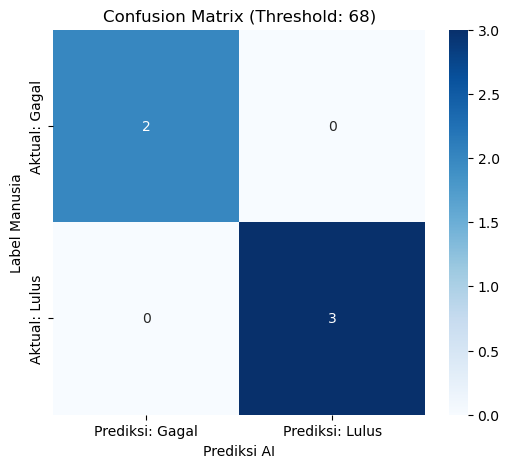


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       Gagal       1.00      1.00      1.00         2
       Lulus       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5


=== SAMPLE ERRORS (AI Salah Prediksi) ===
Hebat! Tidak ada error pada dataset ini.


In [31]:
# 1 = Jawaban Bagus (Lulus), 0 = Jawaban Buruk (Gagal)

video_labels = {
    "interview_question_1.txt": 0, 
    "interview_question_2.txt": 1, 
    "interview_question_3.txt": 0,
    "interview_question_4.txt": 1,
    "interview_question_5.txt": 1
}

# Pertanyaan untuk masing-masing video
video_questions = {
    "interview_question_1.txt": "okay share any specific challenges you face while working on certification how you overcome them",
    "interview_question_2.txt": "can you describe your experience with transfer learning and tensorflow how will it benefit your projects",
    "interview_question_3.txt": "describe a complex models to ensure and efficiency complex model you build accuracy",
    "interview_question_4.txt": "explain how you implement dropout in tensorflow model and the effect it has on training",
    "interview_question_5.txt": "describe the process of building an image classification model"
}

# Data untuk Evaluator
real_video_dataset = []
processed_folder = "data/transcripts_processed" 

import os

for filename in os.listdir(processed_folder):
    if filename in video_labels:
       
        with open(os.path.join(processed_folder, filename), "r", encoding="utf-8") as f:
            transcript_text = f.read()
        
       
        real_video_dataset.append({
            "question": video_questions[filename],
            "answer": transcript_text,
            "human_label": video_labels[filename]
        })

# Evaluasi pada Data Real
print(f"\n--- MENJALANKAN EVALUASI PADA {len(real_video_dataset)} FILE VIDEO ---")

# Inisialisasi Evaluator 
if 'nlp_evaluator' not in globals():
    nlp_evaluator = InterviewEvaluator()
    
evaluator_real = ModelEvaluator(nlp_evaluator)


df_real_results = evaluator_real.run_evaluation(real_video_dataset)

# Cari Threshold Terbaik untuk Data Video 
best_thresh_real = evaluator_real.find_best_threshold()

# Plot Matrix
evaluator_real.plot_confusion_matrix()

# Tampilkan Error
evaluator_real.show_sample_errors()